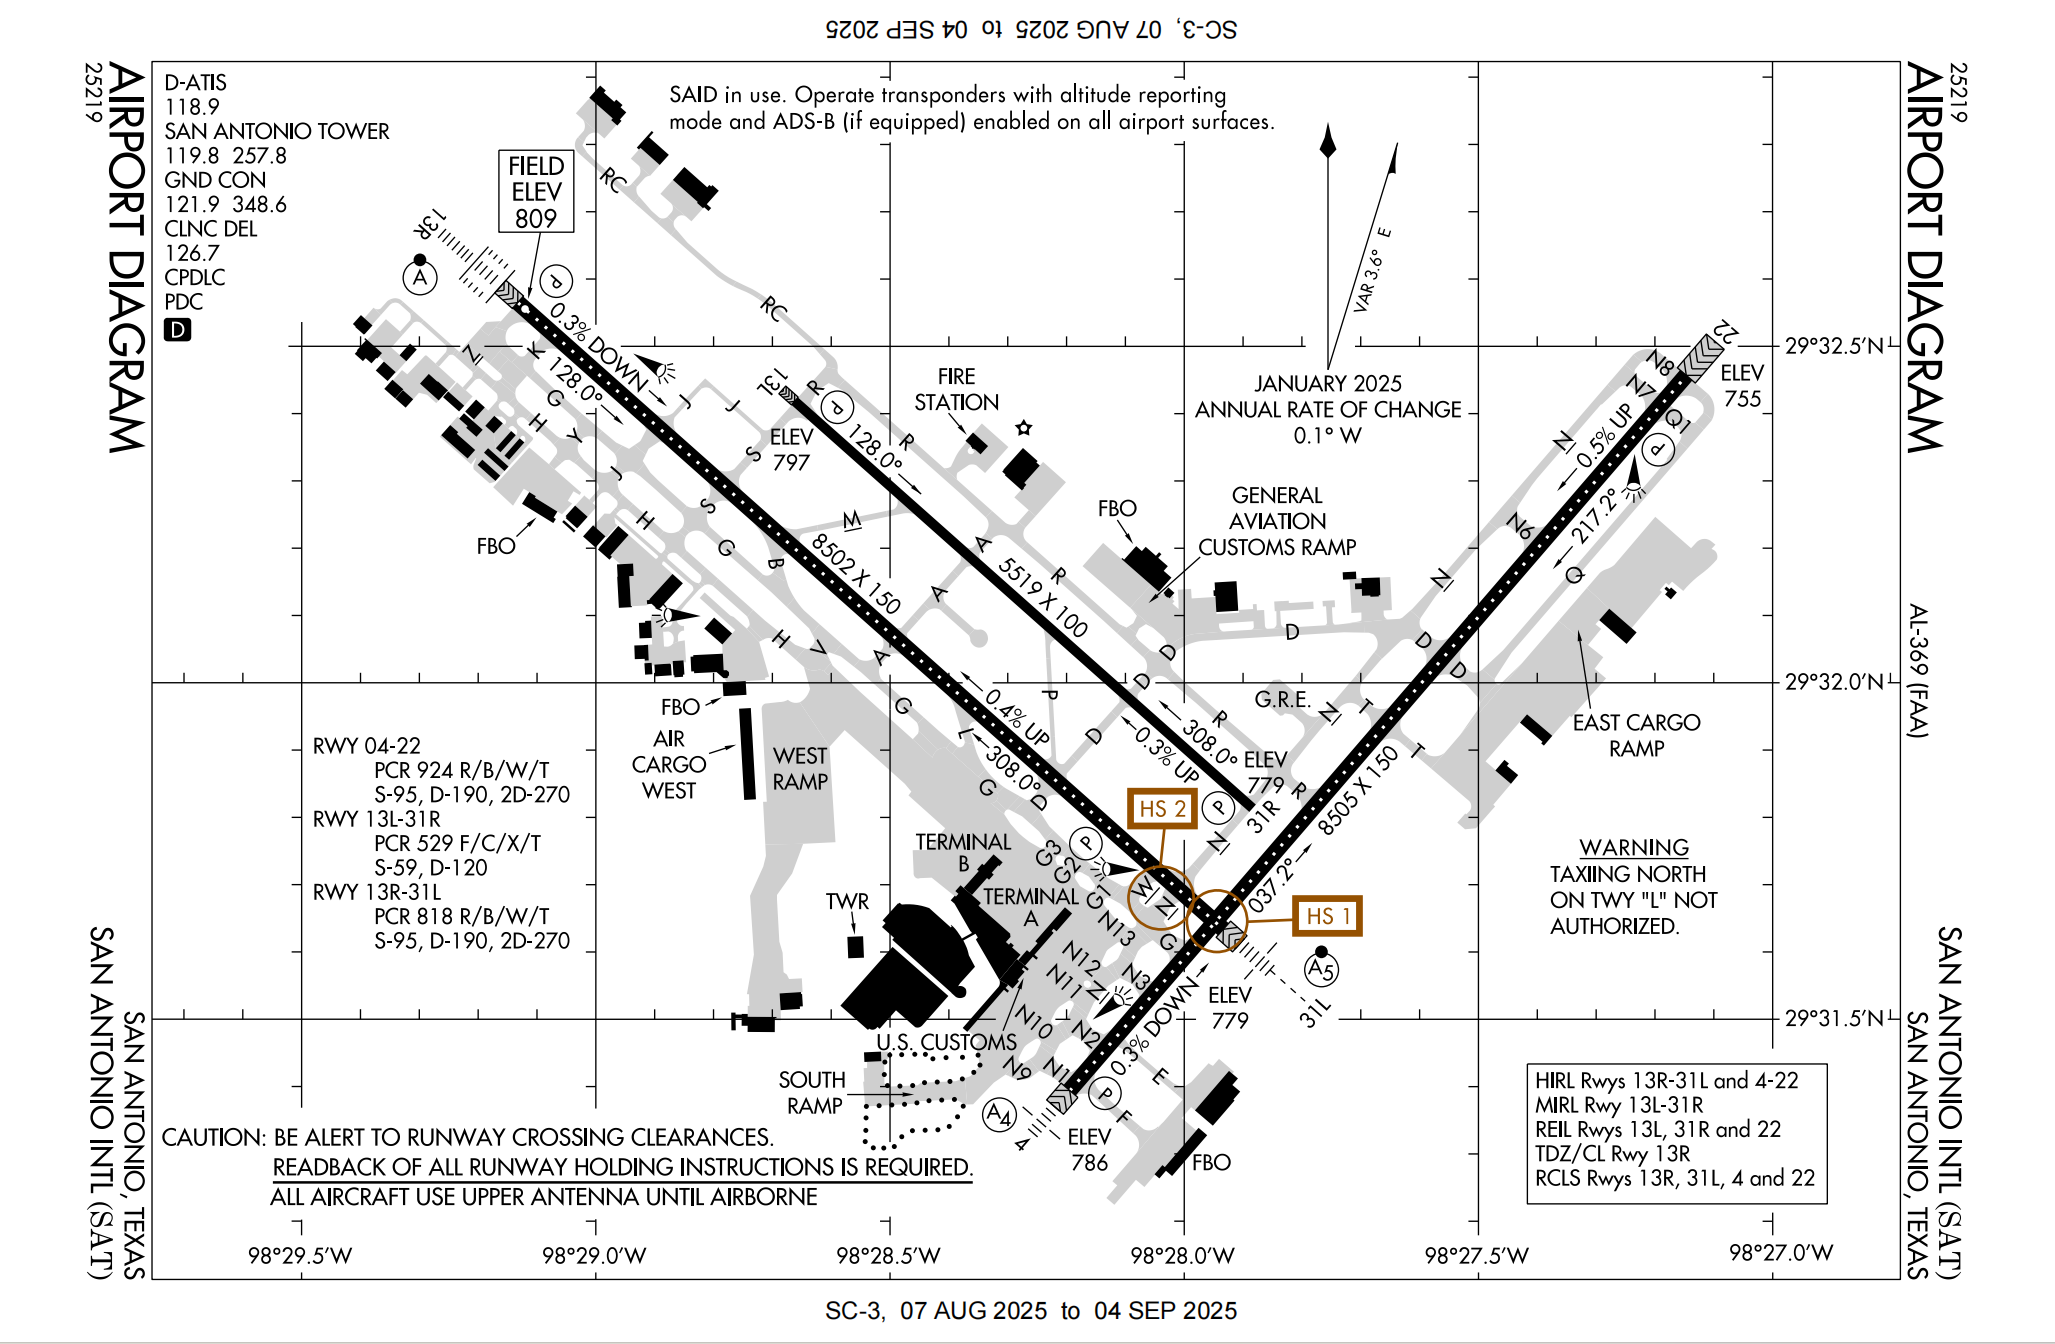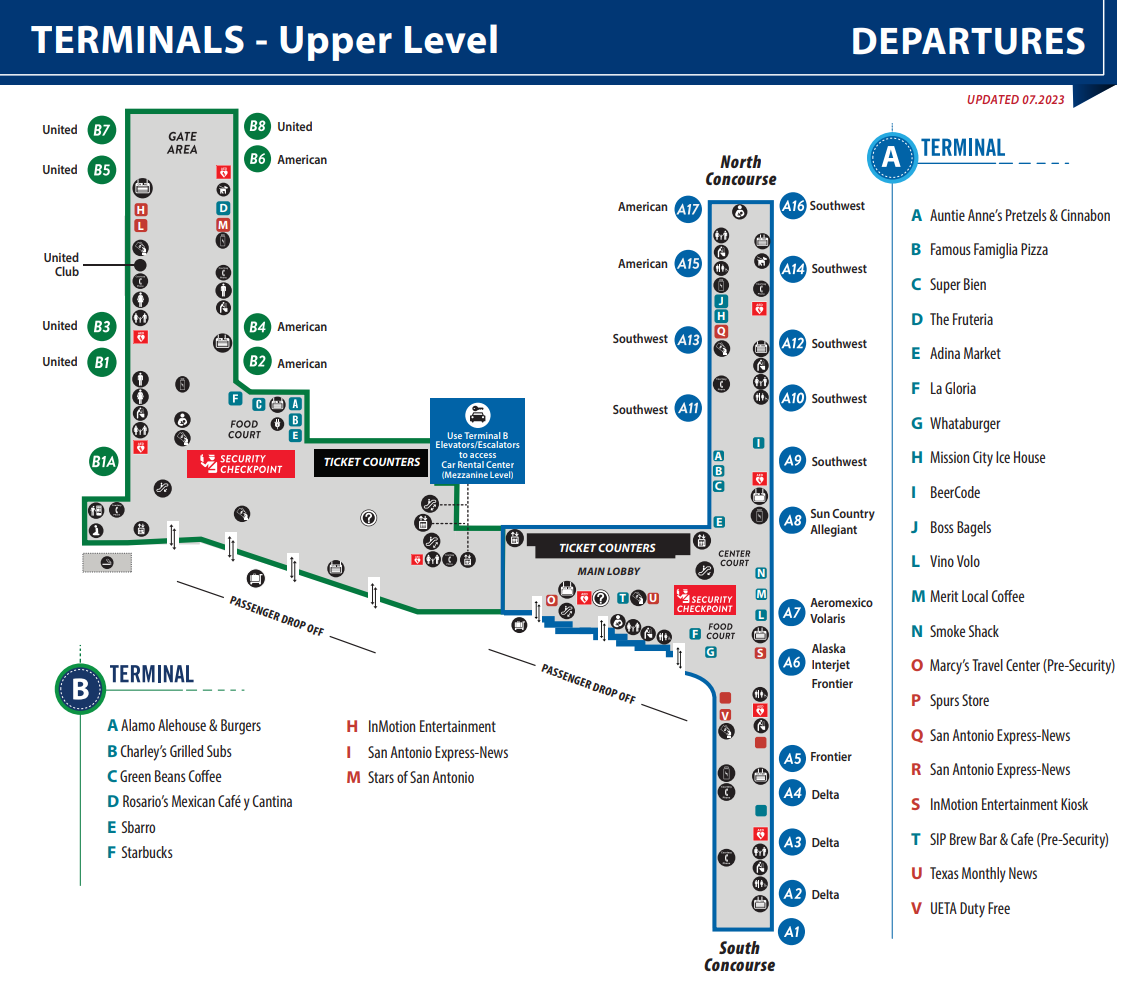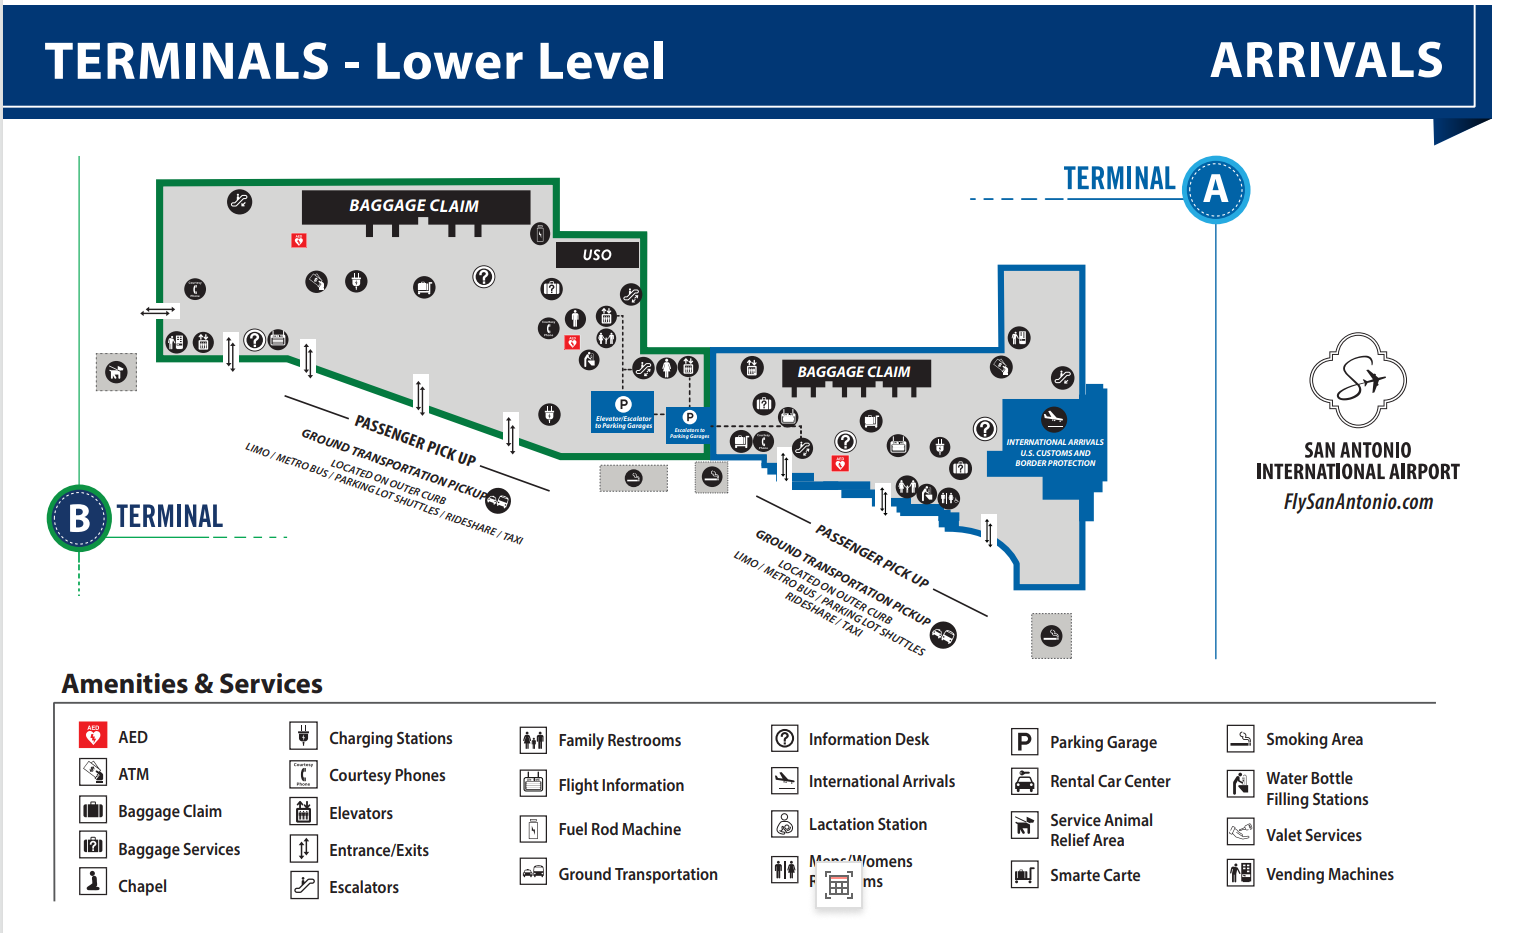

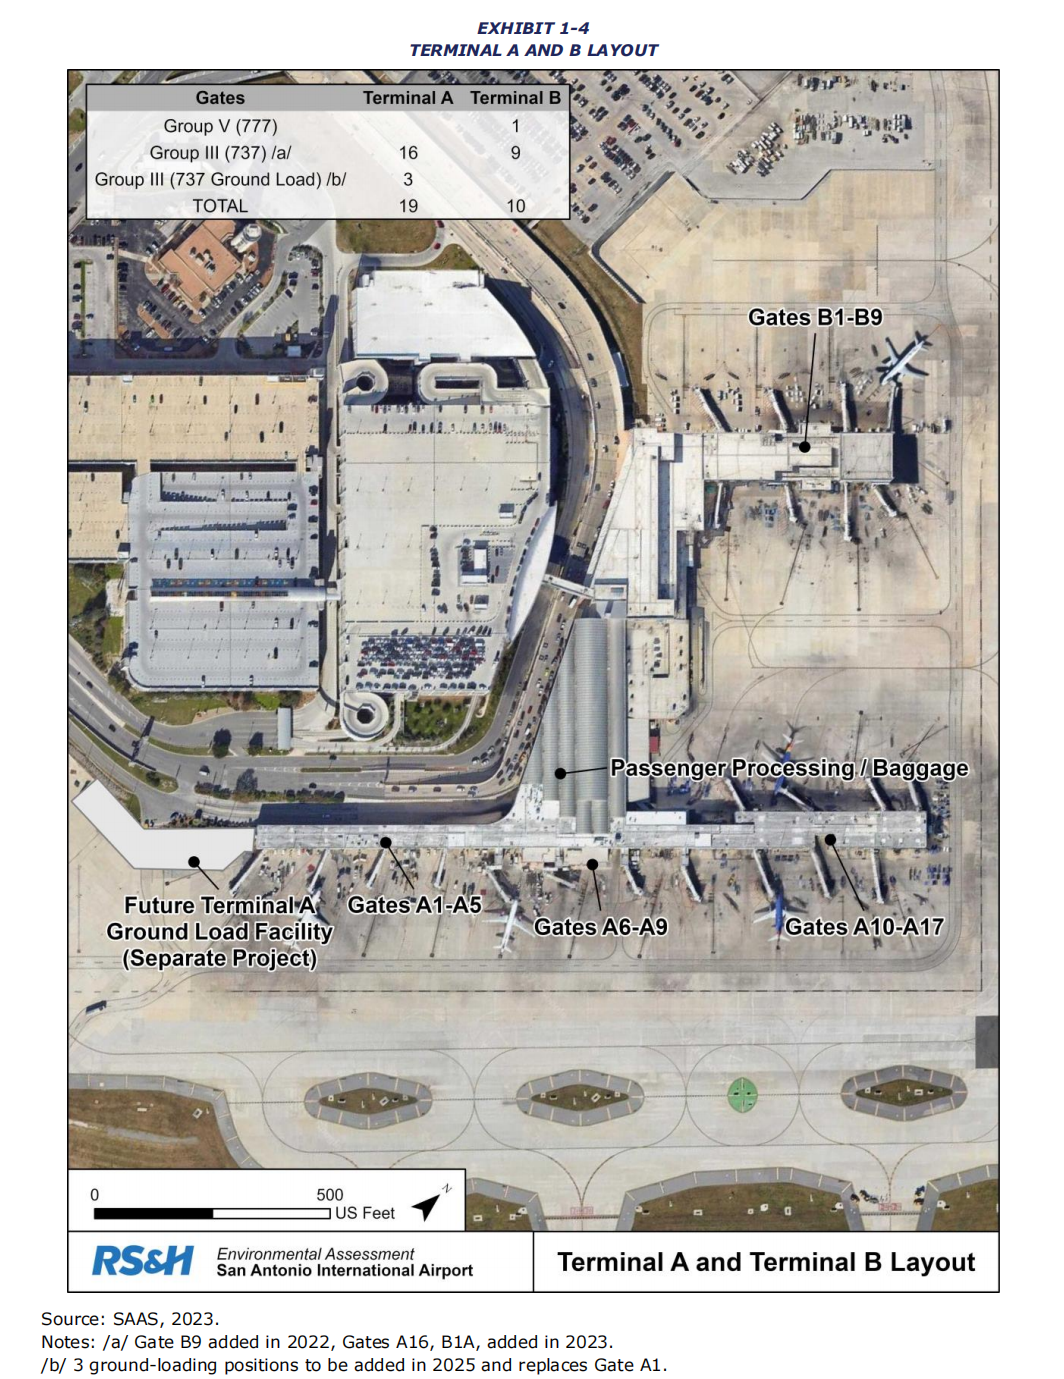

# SAT Daily Departure Quota (Simulation Baseline)

| Airline    | IATA | Terminal | Departures (total) | Domestic | International | Intl gate required | Widebody allowed |
|------------|------|----------|-------------------:|---------:|--------------:|-------------------:|------------------|
| Southwest  | WN   | A        |                 85 |       85 |             0 | False              | False            |
| American   | AA   | B        |                 28 |       28 |             0 | False              | False            |
| United     | UA   | B        |                 20 |       20 |             0 | False              | False            |
| Delta      | DL   | A        |                  6 |        6 |             0 | False              | False            |
| Frontier   | F9   | A        |                  2 |        2 |             0 | False              | False            |
| Alaska     | AS   | A        |                  2 |        2 |             0 | False              | False            |
| Volaris    | Y4   | A        |                  8 |        0 |             8 | True               | False            |
| Aeroméxico | AM   | A        |                  4 |        0 |             4 | True               | False            |
| Sun Country| SY   | A        |                  1 |        1 |             0 | False              | False            |
| Allegiant  | G4   | A        |                  1 |        1 |             0 | False              | False            |
| **Total**  |      |          |               157  |      145 |            12 | —                  | —                |


# SAT Gate Constraint Summary

| Gate ID     | Terminal | Usage Notes                                                                 | Has Jet Bridge | Mapped Stand(s)         |
|-------------|----------|------------------------------------------------------------------------------|----------------|-------------------------|
| A01–A05     | A        | Delta (DL) and Frontier (F9) historically; domestic spillover when needed.  | Yes            | Stands A01–A05          |
| **A06–A07** | A        | **International-capable contact gates** → Volaris (Y4), Aeroméxico (AM).    | Yes            | Stands A06–A07          |
| A08         | A        | ULCC/charter (e.g., Sun Country, Allegiant); usually domestic, configurable for intl ops. | Yes | Stand A08 |
| **A09–A16** | A        | **Southwest (WN) primary cluster** (domestic).                              | Yes            | Stands A09–A16          |
| A17         | A        | American (AA) shown on map; domestic.                                       | Yes            | Stand A17               |
| B01–B09     | B        | **American (AA) & United (UA)**; UA **B-side only**, AA **A/B-side** allowed. | Yes          | Stands B01–B09          |
| **GL1**     | A        | Ground-load gate (bus boarding) → **International** (linked to FIS, for Y4/AM remote ops). | No | Hardstand pool HS01–HS19 |
| **GL2**     | A        | Ground-load gate → **Domestic** (A-side remote ops for WN/others).          | No             | Hardstand pool HS01–HS19 |
| **GL3**     | B        | Ground-load gate → **Domestic** (B-side remote ops for AA/UA overflow).     | No             | Hardstand pool HS01–HS19 |

### Notes
- **Contact gates (26 total)**: A01–A17, B01–B09 → each maps 1:1 to a physical contact stand.
- **Ground-load gates (3 total)**: GL1–GL3 → passengers see a GL gate on FIDS; operations assign the aircraft to one of **19 remote hardstands (HS01–HS19)**.
- **International flights**: use **A06–A07** (contact) or **GL1** (remote with FIS).
- **Domestic flights**: use any domestic-capable contact gate or **GL2/GL3**.
- **Aircraft type**: All scheduled flights modeled as **narrow-body (Code C)** → no widebody compatibility constraint.

---

### Gate-level Constraints (apply to A01–A17 and GL1–GL3)

- **Terminal Legality (Hard Constraint for intl part only)**  
  Each airline can only operate from its allowed terminal(s):  
  - **Southwest (WN)** → A-side only.  
  - **American (AA)** → A-side or B-side.  
  - **United (UA)** → B-side only.  
  - **DL/F9/AS/SY/G4** → A-side only.  
  - **International carriers (Y4, AM)** → A-side only, and must use **A06–A07** or GL1.  

- **Airline Preferences (Soft Constraint)**  
  Within legal terminals, airlines have preferred clusters:  
  - **WN** → prefer **A09–A16**, then spillover to A01–A05, A08, A17.  
  - **AA** → prefer **B01–B09**, then A17, then other A-side domestic gates.  
  - **UA** → B01–B09 only.  
  - **DL/F9/AS** → prefer A01–A05, A08.  
  - **SY/G4** → usually A08.  
  - **Y4/AM** → A06–A07 (international-capable only).  

- **Same-Gate Minimum Buffer (GL gates only)**  
  Two consecutive turns at the **same gate** must be ≥ SGMB minutes apart (e.g., 5–10) beyond turnaround/buffer.  

- **Uniqueness (Gate Level)**  
  Each flight must be assigned **exactly one** gate/GL gate (no multiple gates or partial assignments).

---

### Stand-level Constraints (apply to both contact stands and hardstands HS01–HS19)

- **Stand Preference**  
  Prefer **contact stands**; if none feasible, assign to **remote hardstands** via GL1–GL3.  

- **Same-Stand Minimum Buffer**  
  Two consecutive turns at the **same stand** must be ≥ SGMB minutes apart (in addition to turnaround/buffer).  

- **Adjacent-Stand Conflicts (Double-out / Double-in)**  
  Flights at **adjacent stands** must have ≥ AGSI minutes separation (e.g., 5) for both pushback and docking.  

- **Uniqueness (Stand Level)**  
  Each stand assignment must be unique in time (no double-occupancy).  

- **Preference Relaxation Fallback**  
  If **no feasible assignment** exists after applying all **hard constraints** (international/FIS, terminal legality, SGMB/AGSI, time windows), then **airline preferences may be relaxed**.  
  - Terminal legality **cannot** be relaxed.  
  - International/domestic/FIS rules **cannot** be relaxed.  
  - Only the **airline’s preferred cluster ordering** may be ignored, and any legal gate/stand may be assigned.  

#### Stand Adjacency (for checks — used by Adjacent-Stand Conflicts)
- **Contact stands (1:1 with contact gates)**  
  - A-side stands: A01 ↔ A02 ↔ … ↔ A17  
  - B-side stands: B01 ↔ B02 ↔ … ↔ B09
- **Remote hardstands (HS pool)**  
  - HS01 ↔ HS02 ↔ … ↔ HS19  *(linear adjacency for simulation; replace with actual layout if available)*
- **GL gates**  
  - GL gates are **not stands** and have **no adjacency themselves**.  
  - For GL operations, run the AGSI check on the **assigned hardstand (HSxx)**.



In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from collections import defaultdict
import random

# =========================
# 0) Reproducibility
# =========================
np.random.seed(42)
random.seed(42)

# =========================
# 1) SAT resources & topology
# =========================
# ---- Contact gates (bridge; each has a 1:1 contact STAND with the same ID) ----
A_GATES = [f"A{i:02d}" for i in range(1, 18)]   # A01–A17
B_GATES = [f"B{i:02d}" for i in range(1, 10)]   # B01–B09
CONTACT_GATES = A_GATES + B_GATES           # 26 total

# International-capable CONTACT gates (connected to FIS)
A_INTL_CONTACT = {"A06", "A07"}

# ---- GL gates (no jet bridge; passenger egress doors) ----
# GL1 (A, International), GL2 (A, Domestic), GL3 (B, Domestic)
GL_GATES = ["GL1", "GL2", "GL3"]
GL_META = {
    "GL1": {"Terminal": "A", "Is_International_GL": True},   # A-side, FIS-linked
    "GL2": {"Terminal": "A", "Is_International_GL": False},  # A-side domestic
    "GL3": {"Terminal": "B", "Is_International_GL": False},  # B-side domestic
}

# ---- Remote hardstands (shared pool; STANDS only) ----
HS_POOL = [f"HS{i:02d}" for i in range(1, 20)]  # HS01–HS19

# ---- Collections ----
ALL_GATELIKE = CONTACT_GATES + GL_GATES     # gates passengers see on FIDS
ALL_STANDS   = CONTACT_GATES + HS_POOL      # physical stands: contact stands + hardstands

# ---- Stand adjacency (AGSI checks happen at the STAND level) ----
def linear_adjacency(ids):
    """Immediate neighbors in a linear pier layout (or linearized HS row)."""
    adj = {}
    for i, x in enumerate(ids):
        n = []
        if i > 0: n.append(ids[i-1])
        if i < len(ids)-1: n.append(ids[i+1])
        adj[x] = set(n)
    return adj

STAND_ADJ = {}
STAND_ADJ.update(linear_adjacency(A_GATES))   # A01↔…↔A17
STAND_ADJ.update(linear_adjacency(B_GATES))   # B01↔…↔B09
STAND_ADJ.update(linear_adjacency(HS_POOL))   # HS01↔…↔HS19

# =========================
# 2) Airline rules & daily mix (157 departures)
# =========================
# (Hard) Terminal legality: where an airline is allowed to operate (may be RELAXED in Phase C)
AIRLINE_TERMINAL_ALLOWED = {
    "WN": {"A"},
    "AA": {"A", "B"},
    "UA": {"B"},
    "DL": {"A"},
    "F9": {"A"},
    "AS": {"A"},
    "Y4": {"A"},  # Intl
    "AM": {"A"},  # Intl
    "SY": {"A"},
    "G4": {"A"},
}

# (Soft) Airline preferred clusters inside its legal area (used first, then relaxed)
PREF_CLUSTERS = {
    "WN": [g for g in A_GATES if 9 <= int(g[1:]) <= 16],                  # A09–A16
    "AA": B_GATES + ["A17"] + [g for g in A_GATES if g not in A_INTL_CONTACT],
    "UA": B_GATES,                                          # B only
    "DL": [g for g in A_GATES if int(g[1:]) <= 5] + ["A08"],                # A01–A05, A08
    "F9": [g for g in A_GATES if int(g[1:]) <= 5] + ["A08"],
    "AS": [g for g in A_GATES if int(g[1:]) <= 5],
    "Y4": list(A_INTL_CONTACT),  # A06–A07
    "AM": list(A_INTL_CONTACT),  # A06–A07
    "SY": ["A08"],               # often A08
    "G4": ["A08"],
}

# Daily departures
DAILY_ALLOCATION = {
    "WN": 85, "AA": 28, "UA": 20, "DL": 6, "F9": 2, "AS": 2, "Y4": 8, "AM": 4, "SY": 1, "G4": 1
}
AIRLINE_INTL = {"Y4": True, "AM": True}
is_international = lambda airline: int(AIRLINE_INTL.get(airline, False))

# =========================
# 3) Timetables (planned times) + Delay model (simulated)
# =========================
BASE_DATE = datetime(2025, 8, 21)
DAY_START = BASE_DATE.replace(hour=5, minute=0, second=0, microsecond=0)
DAY_END   = BASE_DATE.replace(hour=23, minute=55, second=0, microsecond=0)

# Weighted schedule (more probability in peaks)
PEAKS = [(6, 9), (16, 19)]
OFFPEAK_WEIGHT = 0.5
PEAK_WEIGHT    = 0.8

def sample_dep_time():
    """Sample a scheduled departure time on a 5-min mesh with peak weighting."""
    minutes, weights = [], []
    t = DAY_START
    while t <= DAY_END:
        h = t.hour
        w = PEAK_WEIGHT if any(a <= h < b for a, b in PEAKS) else OFFPEAK_WEIGHT
        minutes.append(t); weights.append(w)
        t += timedelta(minutes=5)
    idx = np.random.choice(len(minutes), p=np.array(weights)/np.sum(weights))
    # small jitter 0–4 minutes to avoid all flights sitting on exact 5-min marks
    return minutes[idx] + timedelta(minutes=np.random.randint(0, 5))

def sample_turnaround_min():
    """Planned ground time between previous-leg scheduled arrival and scheduled departure."""
    return int(np.random.uniform(45, 75))

# -------- Delay model (time-of-day dependent) --------
# High delay window (e.g., 15:00–17:00): 80% chance to have a delay
DELAY_WINDOW_HIGH = (15, 17)  # [15:00, 17:00)
P_DELAY_HIGH = 0.70
P_DELAY_LOW  = 0.20
SEVERE_FRAC  = 0.20   # among delayed flights, fraction that are "severe"
SEVERE_RANGE = (60, 180)  # minutes
MILD_RANGE   = (10, 45)   # minutes

def sample_inbound_delay_min(dep_time: datetime) -> int:
    """
    Simulate a previous-leg arrival delay (minutes), conditioned on the *departure* time.
    Rationale: late-day departures are more likely to inherit upstream delays.
    """
    h = dep_time.hour
    p = P_DELAY_HIGH if (DELAY_WINDOW_HIGH[0] <= h < DELAY_WINDOW_HIGH[1]) else P_DELAY_LOW
    u1 = np.random.rand()
    if u1 < p:
        # The flight is delayed; decide severity
        u2 = np.random.rand()
        if u2 < SEVERE_FRAC:
            return int(np.random.uniform(*SEVERE_RANGE))
        else:
            return int(np.random.uniform(*MILD_RANGE))
    return 0

# Occupancy windows (PLANNED)
BUFFER_AFTER_DEP_MIN  = 10  # keep resource for a short time after push
REMOTE_EXTRA_BUFFER_MIN = 5   # additional overhead for remote ops (bus/tow)

# Safety spacings
# Contact case: only STAND-level SGMB; GL case: both GATE-level (GL) and STAND-level (HS) SGMB
SGMB_GATE_MIN  = 10   # SGMB applied to GL gates (gate-level) in remote operations
SGMB_STAND_MIN = 10   # SGMB applied to STANDS (contact stands & hardstands)
AGSI_MIN       = 5    # Adjacent-Stand safety interval (double-in/out)

# =========================
# 4) Build departures (PLANNED times + simulated delays)
# =========================
rows = []
for airline, count in DAILY_ALLOCATION.items():
    for _ in range(count):
        dep = sample_dep_time()
        turn = sample_turnaround_min()
        sched_arr_prev = dep - timedelta(minutes=turn)  # planned block-on of previous leg

        # ---- NEW: simulate previous-leg arrival delay and compute actual block-on ----
        inbound_delay_min = sample_inbound_delay_min(dep)
        actual_arr_prev   = sched_arr_prev + timedelta(minutes=inbound_delay_min)

        rows.append({
            "Flight_ID": f"{airline}{np.random.randint(1000, 9999)}",
            "Airline": airline,
            "Is_International": is_international(airline),
            "Scheduled_ARR_prevleg": sched_arr_prev,
            "Inbound_Delay_MIN": inbound_delay_min,
            "Actual_ARR_prevleg": actual_arr_prev,
            "Scheduled_DEP": dep,
        })

# For reporting, sort by planned departure time (or by actual arrival if you prefer for operations)
flights_df = pd.DataFrame(rows).sort_values("Scheduled_DEP").reset_index(drop=True)

# =========================
# 5) Eligibility (HARD legality + Intl/Dom rules) & preference
# =========================
def gate_terminal(g):
    if g in CONTACT_GATES:
        return "A" if g.startswith("A") else "B"
    return GL_META[g]["Terminal"]  # GLs

def is_contact(g): return g in CONTACT_GATES
def is_gl(g):      return g in GL_META

def gate_is_international_capable(g):
    """A06/A07 (contact) and GL1 are international-capable; others are domestic-only."""
    if is_contact(g):
        return g in A_INTL_CONTACT
    return bool(GL_META[g]["Is_International_GL"])  # GL1 True, GL2/GL3 False

def all_candidate_gates_for(airline: str, is_intl: int):
    """
    HARD filter ONLY (Terminal legality RESPECTED):
    - Terminal legality must hold.
    - Intl/Dom rules must hold:
      * Intl → contact must be A06/A07, or GL must be GL1.
      * Dom  → contact must NOT be A06/A07, or GL must be GL2/GL3.
    """
    allowed_terms = AIRLINE_TERMINAL_ALLOWED[airline]
    cands = []
    for g in ALL_GATELIKE:
        if gate_terminal(g) not in allowed_terms:
            continue
        if is_intl:
            if gate_is_international_capable(g):
                cands.append(g)
        else:
            if (is_contact(g) and g not in A_INTL_CONTACT) or (is_gl(g) and not GL_META[g]["Is_International_GL"]):
                cands.append(g)
    return cands

def all_candidate_gates_relax_terminal(is_intl: int):
    """
    HARD filter with Terminal legality RELAXED:
    - Ignore airline's allowed terminals; search airport-wide.
    - Still enforce Intl/Dom rules:
      * Intl → A06/A07 or GL1 only.
      * Dom  → NOT A06/A07; GL2/GL3 only.
    """
    cands = []
    for g in ALL_GATELIKE:
        if is_intl:
            if gate_is_international_capable(g):
                cands.append(g)
        else:
            if (is_contact(g) and g not in A_INTL_CONTACT) or (is_gl(g) and not GL_META[g]["Is_International_GL"]):
                cands.append(g)
    return cands

def preferred_order_for(airline: str, base_list: list[str]) -> list[str]:
    """SOFT: order candidates by airline preference; fallback keeps base order."""
    pref = PREF_CLUSTERS.get(airline, [])
    return sorted(base_list, key=lambda g: (g not in pref, base_list.index(g)))

def contact_first(base_list: list[str]) -> list[str]:
    """Utility: prefer contact gates before GL gates when order is otherwise free."""
    return sorted(base_list, key=lambda g: (g in GL_GATES, base_list.index(g)))

# =========================
# 6) Conflict checks (Gate-level SGMB for GL; Stand-level SGMB & AGSI)
# =========================
# Gate-level occupancy (only used for GL SGMB; contact gates do not use gate-level SGMB)
gate_usage = defaultdict(list)     # { gate_id : [(start, end), ...] }

# Stand-level occupancy & events (used for both contact stands and hardstands)
stand_usage = defaultdict(list)       # { stand_id : [(start, end), ...] }
stand_dock_events = defaultdict(list) # { stand_id : [datetime, ...] }   (double-in checks)
stand_push_events = defaultdict(list) # { stand_id : [datetime, ...] }   (double-out checks)

def no_overlap_with_sgmb(start, end, intervals, sgmb_min):
    """Enforce a minimum spacing (SGMB) between consecutive turns on the SAME resource."""
    pad = timedelta(minutes=sgmb_min)
    for s, e in intervals:
        if not (end + pad <= s or start >= e + pad):
            return False
    return True

def agsi_conflict_on_stand(stand_id, dock_time, push_time):
    """Adjacent-Stand (double-in/out) safety at the STAND level."""
    sep = timedelta(minutes=AGSI_MIN)
    for ngh in STAND_ADJ.get(stand_id, []):
        for t in stand_dock_events.get(ngh, []):
            if abs(dock_time - t) < sep:
                return True
        for t in stand_push_events.get(ngh, []):
            if abs(push_time - t) < sep:
                return True
    return False

# =========================
# 7) Assignment (Gate-level first → if GL then pick a HS stand)
# =========================
assigned_gate  = []
assigned_stand = []
is_remote      = []
assign_src     = []

for _, r in flights_df.iterrows():
    # Decide which "dock" time to use for occupancy (planned)
    dock = r["Scheduled_ARR_prevleg"]
    push = r["Scheduled_DEP"]

    # Occupancy windows:
    # - Contact stand → [dock, push + buffer]
    # - Remote (GL + HS) → [dock, push + buffer + remote extra]
    contact_start, contact_end = dock, push + timedelta(minutes=BUFFER_AFTER_DEP_MIN)
    remote_start,  remote_end  = dock, push + timedelta(minutes=BUFFER_AFTER_DEP_MIN + REMOTE_EXTRA_BUFFER_MIN)

    # Phase A) HARD legality (with terminal legality), then SOFT preferences
    base_candidates = all_candidate_gates_for(r["Airline"], r["Is_International"])
    candidates_pref = preferred_order_for(r["Airline"], base_candidates)

    g_assigned = s_assigned = None
    rem_flag = None

    def try_assign_contact_gate(gate_id):
        """
        CONTACT case: gate == stand.
        - DO NOT enforce GATE-level SGMB (avoid double-padding).
        - Enforce STAND-level SGMB and STAND-level AGSI only.
        """
        stand_id = gate_id  # 1:1 mapping

        # STAND-level SGMB
        if not no_overlap_with_sgmb(contact_start, contact_end, stand_usage[stand_id], SGMB_STAND_MIN):
            return None, None, None

        # STAND-level AGSI (neighbors of this stand)
        if agsi_conflict_on_stand(stand_id, dock, push):
            return None, None, None

        # Reserve: record stand occupancy & events; keep gate_usage for stats (no conflicts checked there)
        stand_usage[stand_id].append((contact_start, contact_end))
        gate_usage[gate_id].append((contact_start, contact_end))
        stand_dock_events[stand_id].append(dock)
        stand_push_events[stand_id].append(push)
        return gate_id, stand_id, 0

    def try_assign_gl_gate(gl_id):
        """
        GL case: need both a GL gate (gate-level resource) and a HS stand (stand-level resource).
        - Enforce GATE-level SGMB on the GL gate.
        - Enforce STAND-level SGMB + STAND-level AGSI on the chosen HS.
        """
        # GATE-level SGMB on the GL itself
        if not no_overlap_with_sgmb(remote_start, remote_end, gate_usage[gl_id], SGMB_GATE_MIN):
            return None, None, None

        # Pick a compatible HS that satisfies stand-level constraints
        for hs in HS_POOL:
            if not no_overlap_with_sgmb(remote_start, remote_end, stand_usage[hs], SGMB_STAND_MIN):
                continue
            if agsi_conflict_on_stand(hs, dock, push):
                continue

            # Reserve GL gate + chosen HS; record HS events
            gate_usage[gl_id].append((remote_start, remote_end))
            stand_usage[hs].append((remote_start, remote_end))
            stand_dock_events[hs].append(dock)
            stand_push_events[hs].append(push)
            return gl_id, hs, 1

        return None, None, None  # no HS available

    # ---- Try Phase A: with preferences (inside legal terminals)
    for g in candidates_pref:
        res = try_assign_contact_gate(g) if g in CONTACT_GATES else try_assign_gl_gate(g)
        if res[0] is not None:
            g_assigned, s_assigned, rem_flag = res
            break

    # Phase B) Preference relaxation (keep terminal legality)
    if g_assigned is None:
        for g in contact_first(base_candidates):  # contact before GL
            res = try_assign_contact_gate(g) if g in CONTACT_GATES else try_assign_gl_gate(g)
            if res[0] is not None:
                g_assigned, s_assigned, rem_flag = res
                break

    # Phase C) Terminal legality relaxation (still keep Intl/Dom, SGMB/AGSI, time windows)
    if g_assigned is None:
        relaxed_cands = contact_first(all_candidate_gates_relax_terminal(r["Is_International"]))
        for g in relaxed_cands:
            res = try_assign_contact_gate(g) if g in CONTACT_GATES else try_assign_gl_gate(g)
            if res[0] is not None:
                g_assigned, s_assigned, rem_flag = res
                break

    # Uniqueness (gate-level): each flight must have exactly one gate/GL assigned
    if g_assigned is None:
        raise RuntimeError(
            f"No feasible assignment for {r['Flight_ID']} even after relaxing terminal legality. "
            f"Consider relaxing SGMB/AGSI, buffers, or adding stands."
        )

    assigned_gate.append(g_assigned)
    assigned_stand.append(s_assigned)
    is_remote.append(rem_flag)
    assign_src.append("contact" if rem_flag == 0 else "remote")

flights_df["Assigned_Gate"]     = assigned_gate
flights_df["Assigned_Stand"]    = assigned_stand
flights_df["Is_Remote"]         = is_remote
flights_df["Assignment_Source"] = assign_src

# =========================
# 8) Outputs & quick stats
# =========================
# For reporting, sort by planned departure time
result_df = flights_df.sort_values("Scheduled_DEP").reset_index(drop=True)

print("Total departures:", len(result_df))
print("Remote assignments:", (result_df["Assignment_Source"] == "remote").sum())
print("\nSample:")
print(result_df[[
    "Flight_ID","Airline","Is_International",
    "Scheduled_ARR_prevleg","Inbound_Delay_MIN","Actual_ARR_prevleg",
    "Scheduled_DEP","Assigned_Gate","Assigned_Stand","Assignment_Source"
]].head(12))

# Simple utilization summaries
def term_of_gate(g):
    if g.startswith("A"): return "A"
    if g.startswith("B"): return "B"
    if g.startswith("GL"): return GL_META[g]["Terminal"]
    return None

util = result_df.assign(TerminalAssigned=result_df["Assigned_Gate"].apply(term_of_gate)) \
                .groupby("TerminalAssigned").size()
print("\nAssigned by terminal:\n", util)

gate_use = result_df[result_df["Assignment_Source"]=="contact"] \
            .groupby("Assigned_Gate").size().sort_values(ascending=False)
gl_use   = result_df[result_df["Assignment_Source"]=="remote"] \
            .groupby("Assigned_Gate").size().sort_values(ascending=False)
hs_use   = result_df[result_df["Assignment_Source"]=="remote"] \
            .groupby("Assigned_Stand").size().sort_values(ascending=False)

print("\nTop contact gates:\n", gate_use.head(10))
print("\nGL gate usage:\n", gl_use)
print("\nTop hardstands:\n", hs_use.head(10))

# Export CSVs
result_df.to_csv("sat_assignment_result.csv", index=False, encoding="utf-8-sig")
# gate_use.rename("count").reset_index().to_csv("sat_contact_gate_usage.csv", index=False, encoding="utf-8-sig")
# gl_use.rename("count").reset_index().to_csv("sat_gl_gate_usage.csv", index=False, encoding="utf-8-sig")
# hs_use.rename("count").reset_index().to_csv("sat_hardstand_usage.csv", index=False, encoding="utf-8-sig")


Total departures: 157
Remote assignments: 1

Sample:
   Flight_ID Airline  Is_International Scheduled_ARR_prevleg  \
0     UA6560      UA                 0   2025-08-21 04:06:00   
1     WN3869      WN                 0   2025-08-21 04:06:00   
2     UA9195      UA                 0   2025-08-21 04:10:00   
3     WN3433      WN                 0   2025-08-21 04:20:00   
4     AA6989      AA                 0   2025-08-21 05:00:00   
5     WN4073      WN                 0   2025-08-21 04:53:00   
6     WN6988      WN                 0   2025-08-21 04:41:00   
7     WN2986      WN                 0   2025-08-21 05:04:00   
8     WN6393      WN                 0   2025-08-21 04:57:00   
9     WN5330      WN                 0   2025-08-21 05:13:00   
10    AA4072      AA                 0   2025-08-21 05:05:00   
11    UA2646      UA                 0   2025-08-21 05:25:00   

    Inbound_Delay_MIN  Actual_ARR_prevleg       Scheduled_DEP Assigned_Gate  \
0                   0 2025-08-21 04

In [ ]:
!pip install gymnasium
!pip install stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 5.6 MB/s eta 0:00:00


In [ ]:
# =========================
# Real-time Reallocation (Operationally realistic)
# =========================
from collections import defaultdict
from datetime import timedelta
import pandas as pd

# =========================
# Effective departure time (45-min turnaround rule)
# =========================
def effective_push_time(row):
    """
    Enforce minimum 45-minute turnaround time.

    If actual turnaround < 45 min:
        effective departure = Actual_ARR_prevleg + 45 min
    Else:
        effective departure = Scheduled_DEP
    """
    turnaround = (
        row["Scheduled_DEP"] - row["Actual_ARR_prevleg"]
    ).total_seconds() / 60.0

    if turnaround < 45:
        return row["Actual_ARR_prevleg"] + timedelta(minutes=45)

    return row["Scheduled_DEP"]


# =========================
# Assignment try-functions
# =========================
def build_contact_try_fn(
    stand_usage, stand_dock_events, stand_push_events,
    sgmb_stand_min=10, agsi_min=5
):
    def _try(gate_id, dock, push):
        stand_id = gate_id  # contact gate ↔ stand 1:1
        start = dock
        end   = push + timedelta(minutes=BUFFER_AFTER_DEP_MIN)

        # Stand-level SGMB
        if not no_overlap_with_sgmb(start, end, stand_usage[stand_id], sgmb_stand_min):
            return None, None, "stand_sgmb_conflict"

        # AGSI check
        if agsi_conflict_on_stand(stand_id, dock, push):
            return None, None, "agsi_conflict"

        # Reserve
        stand_usage[stand_id].append((start, end))
        stand_dock_events[stand_id].append(dock)
        stand_push_events[stand_id].append(push)

        return gate_id, stand_id, None

    return _try


def build_gl_try_fn(
    gate_usage, stand_usage, stand_dock_events, stand_push_events,
    sgmb_gate_min=10, sgmb_stand_min=10, agsi_min=5
):
    def _try(gl_id, dock, push):
        start = dock
        end   = push + timedelta(
            minutes=BUFFER_AFTER_DEP_MIN + REMOTE_EXTRA_BUFFER_MIN
        )

        # Gate-level SGMB
        if not no_overlap_with_sgmb(start, end, gate_usage[gl_id], sgmb_gate_min):
            return None, None, "gate_sgmb_conflict"

        # Try to find a feasible HS stand
        for hs in HS_POOL:
            if not no_overlap_with_sgmb(start, end, stand_usage[hs], sgmb_stand_min):
                continue
            if agsi_conflict_on_stand(hs, dock, push):
                continue

            # Reserve GL gate + HS stand
            gate_usage[gl_id].append((start, end))
            stand_usage[hs].append((start, end))
            stand_dock_events[hs].append(dock)
            stand_push_events[hs].append(push)

            return gl_id, hs, None

        return None, None, "no_hs_available"

    return _try


# =========================
# Original feasibility check (REALISTIC timing)
# =========================
def original_is_feasible(
    row, gate_usage, stand_usage, stand_dock_events, stand_push_events
):
    dock = row["Actual_ARR_prevleg"]
    push = effective_push_time(row)

    # -------- Contact gate --------
    if row["Assigned_Gate"] in CONTACT_GATES:
        stand_id = row["Assigned_Stand"]
        start = dock
        end   = push + timedelta(minutes=BUFFER_AFTER_DEP_MIN)

        if not no_overlap_with_sgmb(start, end, stand_usage[stand_id], SGMB_STAND_MIN):
            return False, "orig_contact_stand_sgmb"
        if agsi_conflict_on_stand(stand_id, dock, push):
            return False, "orig_contact_agsi"

        stand_usage[stand_id].append((start, end))
        stand_dock_events[stand_id].append(dock)
        stand_push_events[stand_id].append(push)

        return True, None

    # -------- GL gate --------
    else:
        gl_id = row["Assigned_Gate"]
        hs_id = row["Assigned_Stand"]
        start = dock
        end   = push + timedelta(
            minutes=BUFFER_AFTER_DEP_MIN + REMOTE_EXTRA_BUFFER_MIN
        )

        if not no_overlap_with_sgmb(start, end, gate_usage[gl_id], SGMB_GATE_MIN):
            return False, "orig_gl_gate_sgmb"
        if not no_overlap_with_sgmb(start, end, stand_usage[hs_id], SGMB_STAND_MIN):
            return False, "orig_gl_stand_sgmb"
        if agsi_conflict_on_stand(hs_id, dock, push):
            return False, "orig_gl_agsi"

        gate_usage[gl_id].append((start, end))
        stand_usage[hs_id].append((start, end))
        stand_dock_events[hs_id].append(dock)
        stand_push_events[hs_id].append(push)

        return True, None


# =========================
# Reallocation replay
# =========================
def reallocate_under_delays(
    day_df: pd.DataFrame,
    allow_terminal_relax: bool = False,
    prefer_contact_first: bool = True,
) -> pd.DataFrame:

    gate_usage = defaultdict(list)
    stand_usage = defaultdict(list)
    stand_dock_events = defaultdict(list)
    stand_push_events = defaultdict(list)

    try_contact = build_contact_try_fn(
        stand_usage, stand_dock_events, stand_push_events,
        sgmb_stand_min=SGMB_STAND_MIN, agsi_min=AGSI_MIN
    )

    try_gl = build_gl_try_fn(
        gate_usage, stand_usage, stand_dock_events, stand_push_events,
        sgmb_gate_min=SGMB_GATE_MIN,
        sgmb_stand_min=SGMB_STAND_MIN,
        agsi_min=AGSI_MIN
    )

    df = day_df.copy()
    df["Gate_Final"] = None
    df["Stand_Final"] = None
    df["Is_Remote_Final"] = None
    df["Realloc_Action"] = None
    df["Realloc_Reason"] = None

    df_proc = df.sort_values(
        ["Actual_ARR_prevleg", "Scheduled_DEP"]
    ).reset_index(drop=True)

    for i, r in df_proc.iterrows():
        dock = r["Actual_ARR_prevleg"]
        push = effective_push_time(r)
        airline = r["Airline"]
        is_intl = r["Is_International"]

        feasible, why_not = original_is_feasible(
            r, gate_usage, stand_usage,
            stand_dock_events, stand_push_events
        )

        if feasible:
            df_proc.at[i, "Gate_Final"] = r["Assigned_Gate"]
            df_proc.at[i, "Stand_Final"] = r["Assigned_Stand"]
            df_proc.at[i, "Is_Remote_Final"] = int(
                r["Assigned_Gate"] in GL_GATES
            )
            df_proc.at[i, "Realloc_Action"] = "kept_original"
            continue

        base_candidates = all_candidate_gates_for(airline, is_intl)
        cand_pref = preferred_order_for(airline, base_candidates)

        def ordered(cands):
            return contact_first(cands) if prefer_contact_first else cands

        g_assigned = s_assigned = None
        reason = why_not

        # Phase A: airline preference
        for g in ordered(cand_pref):
            g2, s2, err = (
                try_contact(g, dock, push)
                if g in CONTACT_GATES
                else try_gl(g, dock, push)
            )
            if g2 is not None:
                g_assigned, s_assigned = g2, s2
                df_proc.at[i, "Realloc_Action"] = "reassigned_pref"
                break

        # Phase B: relax preference
        if g_assigned is None:
            for g in ordered(base_candidates):
                g2, s2, err = (
                    try_contact(g, dock, push)
                    if g in CONTACT_GATES
                    else try_gl(g, dock, push)
                )
                if g2 is not None:
                    g_assigned, s_assigned = g2, s2
                    df_proc.at[i, "Realloc_Action"] = "reassigned_relaxed"
                    break
                reason = err

        # Phase C: relax terminal
        if g_assigned is None and allow_terminal_relax:
            for g in ordered(all_candidate_gates_relax_terminal(is_intl)):
                g2, s2, err = (
                    try_contact(g, dock, push)
                    if g in CONTACT_GATES
                    else try_gl(g, dock, push)
                )
                if g2 is not None:
                    g_assigned, s_assigned = g2, s2
                    df_proc.at[i, "Realloc_Action"] = "reassigned_term_relax"
                    break
                reason = err

        if g_assigned is None:
            df_proc.at[i, "Realloc_Action"] = "failed"
            df_proc.at[i, "Realloc_Reason"] = reason
        else:
            df_proc.at[i, "Gate_Final"] = g_assigned
            df_proc.at[i, "Stand_Final"] = s_assigned
            df_proc.at[i, "Is_Remote_Final"] = int(g_assigned in GL_GATES)
            df_proc.at[i, "Realloc_Reason"] = why_not

    return df_proc.sort_values("Scheduled_DEP").reset_index(drop=True)


In [ ]:
# =========================
# Profile B (Hierarchical)
# Hard-first reward shaping
# WITH try-next-gate fallback
# =========================

"""
Profile B: Hierarchical Real-Time Gate Reassignment Environment

Key design principles:
----------------------
1. KEEP IS NOT AN ACTION.
   - If the originally assigned gate remains feasible, the environment
     automatically keeps it without consulting the agent.
   - This mirrors real-world airport operations and rule-based baselines.

2. The agent is invoked ONLY when reassignment is required.
   - The agent selects a gate index.
   - The environment handles feasibility checks and fallback internally.

3. Hard constraints first, soft preferences second.
   - AGSI / SGMB enforced at decision time.
   - Soft preferences are encoded via small shaping rewards.

4. Explicit try-next-gate fallback.
   - If the selected gate is infeasible, subsequent gates are tried.
   - Each skipped gate incurs a fallback penalty.

This formulation avoids the pathological behavior where DRL
unnecessarily reassigns already-feasible flights.
"""

import numpy as np
from collections import defaultdict
import pandas as pd
import gymnasium as gym
from gymnasium import spaces


# ============================================================
# Reward configuration (ONLY for reassignment decisions)
# ============================================================

# Base rewards for successful reassignment
R_ASSIGN_CONTACT_OK = 1.0
R_ASSIGN_GL_OK = 0.6

# Failure penalty (no feasible gate found)
R_FAIL_ILLEGAL = -2.0

# Penalty per fallback step
R_FALLBACK_PENALTY = -0.2

# Soft shaping bonuses
BONUS_GL_HS_SUCCESS = 0.05
ALPHA_DIST_PER_INDEX = -0.03
AIRLINE_PREF_BONUS = 0.10
SAME_PIER_BONUS = 0.05


# Gate index lookup (for distance-based shaping)
_G2IDX = {g: i for i, g in enumerate(ALL_GATELIKE)}


# ============================================================
# Shaping helper functions
# ============================================================

def same_pier(g1, g2):
    """
    Return True if two gates belong to the same terminal / pier.
    """
    if g1 is None or g2 is None:
        return False
    return gate_terminal(g1) == gate_terminal(g2)


def airline_pref_hit(airline, gate_id):
    """
    Check whether a gate belongs to the airline's preferred cluster.
    """
    return gate_id in set(PREF_CLUSTERS.get(airline, []))


def compute_shaping_bonus(
    airline,
    assigned_gate,
    original_gate,
    is_gl,
    gl_pair_ok
):
    """
    Compute small additive shaping bonus reflecting soft operational preferences.

    Components:
    - GL + hard-stand pairing success
    - Distance from original gate
    - Airline gate preference
    - Same-pier continuity
    """
    bonus = 0.0

    if is_gl and gl_pair_ok:
        bonus += BONUS_GL_HS_SUCCESS

    if assigned_gate is not None and original_gate is not None:
        di = abs(_G2IDX[assigned_gate] - _G2IDX[original_gate])
        bonus += ALPHA_DIST_PER_INDEX * float(di)

    if airline_pref_hit(airline, assigned_gate):
        bonus += AIRLINE_PREF_BONUS

    if same_pier(assigned_gate, original_gate):
        bonus += SAME_PIER_BONUS

    return float(bonus)


# ============================================================
# Environment definition
# ============================================================

class SATRealTimeGateEnv_ProfileB(gym.Env):
    """
    Hierarchical real-time gate reassignment environment (Profile B).

    Decision logic:
    ----------------
    Step 1 (environment):
        - Check whether the originally assigned gate is still feasible.
        - If yes: automatically keep it (no agent action, zero reward).

    Step 2 (agent, only if needed):
        - Agent selects a gate index.
        - Environment applies try-next-gate fallback if infeasible.

    This design aligns DRL behavior with real operational procedures.
    """

    metadata = {"render.modes": ["human"]}

    def __init__(self, day_df: pd.DataFrame):
        super().__init__()

        self.base_df = day_df.copy()

        # Action space: ONLY gate indices (no KEEP action)
        self.action_map = list(ALL_GATELIKE)
        self.num_actions = len(self.action_map)
        self.action_space = spaces.Discrete(self.num_actions)

        # Airline encoding
        self.airlines = sorted(self.base_df["Airline"].unique())
        self.air_idx = {a: i for i, a in enumerate(self.airlines)}

        feat_dim = 6 + len(self.airlines)
        self.observation_space = spaces.Dict({
            "flight_features": spaces.Box(0.0, 1.0, (feat_dim,), dtype=np.float32),
            "gate_mask": spaces.MultiBinary(self.num_actions)
        })

        self.reset()

    # --------------------------------------------------------
    # Effective departure time (45-minute turnaround rule)
    # --------------------------------------------------------

    def _effective_push(self, row):
        """
        Enforce minimum 45-minute turnaround time.
        """
        turnaround = (
            row["Scheduled_DEP"] - row["Actual_ARR_prevleg"]
        ).total_seconds() / 60.0

        if turnaround < 45:
            return row["Actual_ARR_prevleg"] + pd.Timedelta(minutes=45)

        return row["Scheduled_DEP"]

    # --------------------------------------------------------
    # Usage trackers and feasibility builders
    # --------------------------------------------------------

    def _reset_usage(self):
        """
        Reset gate / stand usage trackers.
        """
        self.gate_usage = defaultdict(list)
        self.stand_usage = defaultdict(list)
        self.stand_dock_events = defaultdict(list)
        self.stand_push_events = defaultdict(list)

        self.try_contact = build_contact_try_fn(
            self.stand_usage,
            self.stand_dock_events,
            self.stand_push_events,
            sgmb_stand_min=SGMB_STAND_MIN,
            agsi_min=AGSI_MIN
        )

        self.try_gl = build_gl_try_fn(
            self.gate_usage,
            self.stand_usage,
            self.stand_dock_events,
            self.stand_push_events,
            sgmb_gate_min=SGMB_GATE_MIN,
            sgmb_stand_min=SGMB_STAND_MIN,
            agsi_min=AGSI_MIN
        )

    # --------------------------------------------------------
    # Observation helpers
    # --------------------------------------------------------

    def _norm_time(self, t):
        """
        Normalize time of day to [0, 1].
        """
        return (t.hour * 60 + t.minute) / (24 * 60)

    def _air_onehot(self, airline):
        """
        One-hot encode airline identity.
        """
        v = np.zeros(len(self.airlines), dtype=np.float32)
        v[self.air_idx[airline]] = 1.0
        return v

    def _gate_mask(self, row):
        """
        Compute feasibility mask over all gates
        using time-consistent dry-run checks.
        """
        dock = row["Actual_ARR_prevleg"]
        push = self._effective_push(row)
        airline, is_intl = row["Airline"], row["Is_International"]

        legal = set(all_candidate_gates_for(airline, is_intl))
        mask = np.zeros(self.num_actions, dtype=np.int8)

        for i, g in enumerate(self.action_map):
            if g not in legal:
                continue

            if g in CONTACT_GATES:
                g2, s2, _ = self.try_contact(g, dock, push)
            else:
                g2, s2, _ = self.try_gl(g, dock, push)

            if g2 is not None:
                mask[i] = 1

                # rollback dry-run reservation
                if g in CONTACT_GATES:
                    self.stand_usage[s2].pop()
                    self.stand_dock_events[s2].pop()
                    self.stand_push_events[s2].pop()
                else:
                    self.gate_usage[g].pop()
                    self.stand_usage[s2].pop()
                    self.stand_dock_events[s2].pop()
                    self.stand_push_events[s2].pop()

        return mask

    # --------------------------------------------------------
    # Gym API
    # --------------------------------------------------------

    def reset(self, *, seed=None, options=None):
        """
        Reset environment state.
        """
        super().reset(seed=seed)

        self.df = self.base_df.sort_values(
            ["Actual_ARR_prevleg", "Scheduled_DEP"]
        ).reset_index(drop=True)

        self.idx = 0
        self._reset_usage()

        return self._get_obs(), {}

    def _get_obs(self):
        """
        Construct observation for the current flight.
        """
        if self.idx >= len(self.df):
            dim = self.observation_space["flight_features"].shape[0]
            return {
                "flight_features": np.zeros(dim, dtype=np.float32),
                "gate_mask": np.zeros(self.num_actions, dtype=np.int8)
            }

        r = self.df.iloc[self.idx]
        dock = r["Actual_ARR_prevleg"]
        push = self._effective_push(r)

        delay = (dock - r["Scheduled_ARR_prevleg"]).total_seconds() / 60.0

        feat = np.concatenate([
            np.array([
                self._norm_time(dock),
                self._norm_time(push),
                np.clip(delay / 180.0, 0.0, 1.0),
                float(r["Is_International"]),
                max(0.0, (push - dock).total_seconds() / 3600.0) / 6.0,
                1.0 if r["Assigned_Gate"] in GL_GATES else 0.0
            ], dtype=np.float32),
            self._air_onehot(r["Airline"])
        ])

        return {
            "flight_features": feat,
            "gate_mask": self._gate_mask(r)
        }

    # --------------------------------------------------------
    # STEP: hierarchical decision with fallback
    # --------------------------------------------------------

    def step(self, action: int):
        """
        Execute one environment step.

        If original assignment is feasible:
            - Automatically keep it
            - Reward = 0.0
            - Agent is bypassed

        Otherwise:
            - Agent-selected gate is attempted
            - try-next-gate fallback is applied
        """
        info = {}
        r = self.df.iloc[self.idx]

        dock = r["Actual_ARR_prevleg"]
        push = self._effective_push(r)

        airline = r["Airline"]
        orig_gate = r["Assigned_Gate"]

        # --------------------------------------------------
        # Stage 1: automatic KEEP if feasible
        # --------------------------------------------------
        feas, _ = original_is_feasible(
            r,
            self.gate_usage,
            self.stand_usage,
            self.stand_dock_events,
            self.stand_push_events
        )

        if feas:
            reward = 0.0
            info["decision"] = ("auto_keep", orig_gate, r["Assigned_Stand"])

        # --------------------------------------------------
        # Stage 2: agent-driven reassignment
        # --------------------------------------------------
        else:
            start_idx = action
            fallback_steps = 0
            assigned = False

            for j in range(start_idx, len(self.action_map)):
                g = self.action_map[j]

                if g in CONTACT_GATES:
                    g2, s2, ok = self.try_contact(g, dock, push)
                else:
                    g2, s2, ok = self.try_gl(g, dock, push)

                if g2 is not None:
                    base = (
                        R_ASSIGN_GL_OK if g in GL_GATES
                        else R_ASSIGN_CONTACT_OK
                    )

                    reward = (
                        base
                        + compute_shaping_bonus(
                            airline,
                            g2,
                            orig_gate,
                            g in GL_GATES,
                            ok
                        )
                        + fallback_steps * R_FALLBACK_PENALTY
                    )

                    info["decision"] = (
                        "assign_ok" if fallback_steps == 0 else "assign_fallback",
                        g2,
                        s2
                    )
                    info["fallback_steps"] = fallback_steps
                    assigned = True
                    break

                fallback_steps += 1

            if not assigned:
                reward = R_FAIL_ILLEGAL
                info["decision"] = ("assign_fail", None, None)

        self.idx += 1
        done = self.idx >= len(self.df)

        return self._get_obs(), float(reward), done, False, info


In [ ]:
def run_inference_unified(
    env,
    model,
    *,
    model_name="UNKNOWN",
    deterministic,
    seed=None
):
    """
    Unified inference pipeline for DRL models (PPO / A2C / DQN).

    Compatible with:
    - Profile A (flat decision)
    - Profile B (hierarchical: auto-keep + agent-only-reassign)

    Key semantics (Profile B):
    --------------------------
    - KEEP is NOT an action.
    - If original gate is feasible, the environment auto-keeps it.
    - Agent action is only meaningful when reassignment is required.
    """

    import numpy as np
    import pandas as pd

    # unwrap vectorized env
    real_env = env.envs[0] if hasattr(env, "envs") else env

    # reset environment
    try:
        obs, _ = env.reset(seed=seed)
    except TypeError:
        obs, _ = env.reset()

    total_reward = 0.0
    records = []

    ACTION_MAP = real_env.action_map

    while True:

        # ---------- agent prediction ----------
        action, _ = model.predict(obs, deterministic=deterministic)

        # ---------- environment step ----------
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += float(reward)

        # ---------- logging ----------
        idx = real_env.idx - 1
        if 0 <= idx < len(real_env.df):
            row = real_env.df.iloc[idx]

            decision = info.get("decision")

            if decision is not None:
                dec_type, gate_final, stand_final = decision
                is_remote_final = (
                    int(gate_final in GL_GATES)
                    if gate_final is not None
                    else None
                )
            else:
                dec_type = "unknown"
                gate_final = None
                stand_final = None
                is_remote_final = None

            # agent-selected starting gate (only meaningful if reassigned)
            chosen_gate = (
                ACTION_MAP[int(action)]
                if dec_type != "auto_keep"
                else None
            )

            airline_pref_ok = (
                gate_final in PREF_CLUSTERS.get(row["Airline"], [])
                if gate_final is not None
                else None
            )

            records.append({
                "Flight_ID": row["Flight_ID"],
                "Airline": row["Airline"],
                "Is_International": row["Is_International"],
                "Actual_ARR_prevleg": row["Actual_ARR_prevleg"],
                "Scheduled_DEP": row["Scheduled_DEP"],

                "Gate_Original": row["Assigned_Gate"],
                "Stand_Original": row["Assigned_Stand"],

                "Model_Name": model_name,

                # agent intent (may be ignored by env)
                "Action_Index": int(action),
                "Action_Chosen_Gate": chosen_gate,

                # environment outcome
                "Decision_Type": dec_type,
                "Gate_Final": gate_final,
                "Stand_Final": stand_final,
                "Is_Remote_Final": is_remote_final,

                "Airline_Pref_OK": airline_pref_ok,
                "Reward": float(reward),
            })

        if terminated or truncated:
            break

    return total_reward, pd.DataFrame(records)


In [ ]:
# ============================
# Train A3C-style (A2C) for Profile B
# ============================
from stable_baselines3 import A2C
from stable_baselines3.common.vec_env import DummyVecEnv

env_B = DummyVecEnv([lambda: SATRealTimeGateEnv_ProfileB(result_df)])
env_B.seed(42)

a3c_model_B = A2C(
    policy="MultiInputPolicy",
    env=env_B,
    learning_rate=1e-3,
    gamma=0.99,
    n_steps=5,
    ent_coef=0.01,
    verbose=1
)

a3c_model_B.learn(total_timesteps=200_000)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------
| time/                 |          |
|    fps                | 214      |
|    iterations         | 100      |
|    time_elapsed       | 2        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -3.34    |
|    explained_variance | -25.8    |
|    learning_rate      | 0.001    |
|    n_updates          | 99       |
|    policy_loss        | -0.577   |
|    value_loss         | 0.0725   |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


流式输出内容被截断，只能显示最后 5000 行内容。
|    value_loss         | 0.0557   |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 202      |
|    iterations         | 4400     |
|    time_elapsed       | 108      |
|    total_timesteps    | 22000    |
| train/                |          |
|    entropy_loss       | -3       |
|    explained_variance | -1.13    |
|    learning_rate      | 0.001    |
|    n_updates          | 4399     |
|    policy_loss        | 0.653    |
|    value_loss         | 0.157    |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 203      |
|    iterations         | 4500     |
|    time_elapsed       | 110      |
|    total_timesteps    | 22500    |
| train/                |          |
|    entropy_loss       | -3.01    |
|    explained_variance | 0.932    |
|    learning_rate      | 0.001    |
|    n_upda

In [ ]:
# ============================
# Train PPO for Profile B
# ============================
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

env_PPO_B = DummyVecEnv([lambda: SATRealTimeGateEnv_ProfileB(result_df)])
env_PPO_B.seed(42)

ppo_model_B = PPO(
    policy="MultiInputPolicy",
    env=env_PPO_B,
    learning_rate=1e-3,
    n_steps=2048,
    batch_size=128,
    gamma=0.99,
    verbose=1
)

ppo_model_B.learn(total_timesteps=200_000)


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 143  |
|    iterations      | 1    |
|    time_elapsed    | 14   |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 159         |
|    iterations           | 2           |
|    time_elapsed         | 25          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.015883151 |
|    clip_fraction        | 0.172       |
|    clip_range           | 0.2         |
|    entropy_loss         | -3.36       |
|    explained_variance   | -0.106      |
|    learning_rate        | 0.001       |
|    loss                 | 0.305       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0421     |
|    value_loss           | 1.07        |
-----------------------------------------
-----------------

In [ ]:
import gymnasium as gym
import numpy as np

class FlattenObsWrapper(gym.ObservationWrapper):
    """
    Convert Dict(flight_features, gate_mask) → flat vector for DQN.

    IMPORTANT:
    - This wrapper MUST expose env-level attributes
      (num_actions, action_map, df, idx, etc.)
      for unified inference & evaluation.
    """

    def __init__(self, env):
        super().__init__(env)

        # -------------------------
        # Flattened observation
        # -------------------------
        feat_dim = env.observation_space["flight_features"].shape[0]
        mask_dim = env.observation_space["gate_mask"].shape[0]
        self.flat_dim = feat_dim + mask_dim

        low  = np.zeros(self.flat_dim, dtype=np.float32)
        high = np.ones(self.flat_dim, dtype=np.float32)

        self.observation_space = gym.spaces.Box(
            low=low,
            high=high,
            dtype=np.float32
        )

        # -------------------------
        # 🔑 Attribute passthrough
        # -------------------------
        # action semantics
        self.num_actions = env.num_actions
        self.action_map = env.action_map

        # episode / logging state
        self.df = None
        self.idx = None

    # -------------------------
    # Observation transform
    # -------------------------
    def observation(self, obs):
        return np.concatenate(
            [obs["flight_features"], obs["gate_mask"]]
        ).astype(np.float32)

    # -------------------------
    # Keep env state in sync
    # -------------------------
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.df = self.env.df
        self.idx = self.env.idx
        return self.observation(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.idx = self.env.idx
        return self.observation(obs), reward, terminated, truncated, info


In [ ]:
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv

# ---------- Train DQN for Profile B ----------
def make_env_B():
    env = SATRealTimeGateEnv_ProfileB(result_df)
    env = FlattenObsWrapper(env)
    return env

vecB = DummyVecEnv([make_env_B])
vecB.seed(42)

dqn_model_B = DQN(
    policy="MlpPolicy",
    env=vecB,
    learning_rate=1e-3,
    batch_size=128,
    gamma=0.99,

    buffer_size=100_000,
    learning_starts=5_000,
    target_update_interval=1_000,

    exploration_fraction=0.1,
    exploration_final_eps=0.05,
    verbose=1
)

dqn_model_B.learn(total_timesteps=200_000)

Using cpu device
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.97     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 247      |
|    time_elapsed     | 2        |
|    total_timesteps  | 628      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.94     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 304      |
|    time_elapsed     | 4        |
|    total_timesteps  | 1256     |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.911    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 333      |
|    time_elapsed     | 5        |
|    total_timesteps  | 1884     |
----------------------------------
----------------------------------
| r

# Unified Parameter Table (PPO / DQN / A3C)  
### *With Explanation: All models intentionally share similar hyperparameters to enable fair comparison.*

Below is a consolidated table of *all* hyperparameters used for **PPO**, **A3C (A2C)**, and **DQN**, across **Profile A** and **Profile B**.  
Where possible, the parameters were chosen to be **aligned** across methods, so the comparison focuses on **algorithmic differences**, not tuning differences.

# **1. Hyperparameter Comparison Table**

| Algorithm | Profile | Policy | Env Wrapper | Learning Rate | Batch Size | γ (Discount) | Rollout Steps | Exploration Settings | Entropy Coef | Total Timesteps | Notes |
|----------|----------|--------|-------------|----------------|-------------|----------------|----------------|------------------------|-----------------|---------------------|-------|
| **PPO** | A | MultiInputPolicy | DummyVecEnv | **1e-3** | **128** | default(0.99) | **2048** | N/A | default | **200k** | Large rollout for stable updates |
| **PPO** | B | MultiInputPolicy | DummyVecEnv | **1e-3** | **128** | default(0.99) | **2048** | N/A | default | **200k** | Same settings → fairness |
| **A3C (A2C)** | A | MultiInputPolicy | DummyVecEnv | **1e-3** | N/A | **0.99** | **5** | N/A | **0.01** | **200k** | Short rollout because A2C uses synchronous advantage updates |
| **A3C (A2C)** | B | MultiInputPolicy | DummyVecEnv | **1e-3** | N/A | **0.99** | **5** | N/A | **0.01** | **200k** | Same settings → fairness |
| **DQN** | A | MlpPolicy | FlattenObsWrapper + DummyVecEnv | **1e-3** | **128** | **0.99** | N/A | **0.1 → 0.05** | N/A | **200k** | Requires flattened obs |
| **DQN** | B | MlpPolicy | FlattenObsWrapper + DummyVecEnv | **1e-3** | **128** | **0.99** | N/A | **0.1 → 0.05** | N/A | **200k** | Same settings → fairness |

---

# **2. Why These Parameters Were Unified**

To ensure that the comparison focuses on the *algorithm*, not the tuning, the parameter choices follow three fairness design principles:

## **(1) Identical learning rate across all algorithms: `1e-3`**  
This keeps all agents on the same “learning speed”, removing optimization bias.

## **(2) Identical training duration: `200,000` timesteps**  
Makes rewards comparable across methods.

## **(3) Similar batch sizes when applicable (`128`)**  
PPO and DQN both use minibatches.  
A3C does not use minibatches (on-policy algorithm), but its training intensity is comparable.

# **3. Why Some Parameters Are Algorithm-Specific**

Some settings are *inherent* to the algorithm:

### PPO  
- Needs **long rollouts (`2048`)** to estimate advantages.  
- Uses **batch_size** parameter.

### A3C (A2C in SB3)  
- Always uses **short rollouts (`n_steps = 5`)**.  
- Does **not** use batch_size.

### DQN  
- Requires **flat observations**, so use `FlattenObsWrapper`.  
- Uses ε-greedy exploration:  
  - exploration_fraction = **0.1**  
  - final epsilon = **0.05**

These differences do not harm fairness because they are **required** for each algorithm to function.

# **4. High-Level Explanation**

To ensure a fair comparison between PPO, A3C, and DQN on the airport gate-assignment problem,  
all three algorithms were trained under **consistent hyperparameters**:

- **Same learning rate (1e-3)**  
- **Same number of timesteps (200k)**  
- **Same vectorized environment structure (DummyVecEnv)**  
- **Same underlying observation/state design** (dict-based for PPO/A3C, flattened for DQN)  
- **Same reward system and same training dataset**  
- **Same action space and same gate/stand constraints**

The only hyperparameters that differ are those **intrinsic to each algorithm’s learning procedure**  
(e.g., PPO’s rollout size, A2C’s n_steps, DQN’s epsilon schedule), which cannot be aligned without breaking the algorithm.

Thus, the performance differences originate from the **algorithms themselves**, not from tuning bias.

# **5. Summary: Why This Setup Is Scientifically Valid**

✔ Controls major factors (LR, timesteps, data, batch size)  
✔ Uses the same environment logic and reward signals  
✔ Fits each algorithm’s best-practice configuration  
✔ Ensures differences in performance reflect **algorithmic capability**, not hyperparameter artifacts.



# 6. Evaluation Dimensions for Comparing PPO, DQN, and A3C  
*(with Profile A and Profile B Gate-Assignment Environments)*

To compare the reinforcement-learning algorithms fairly (PPO, DQN, A3C),  
I evaluated them on a **unified set of metrics** that measure both **reward performance** and **operational behavior** inside the airport gate-assignment environment.

# **Comparison Metrics Used**

## **Total Reward**
The primary RL metric.  
It represents how well each model balances:
- keeping feasible assignments  
- successful reallocation  
- minimizing operational conflicts  
- avoiding illegal actions  
- respecting GL/HS constraints  
- preserving buffers  

Higher reward → better global decision quality.

## **Decision Breakdown**
Shows how often each model chooses:
- `keep_ok` — keeping original assignment when it is feasible  
- `assign_ok` — successful reassignment  
- `keep_fail` — attempted to keep but infeasible (bad)  
- `assign_fail` — illegal reassignment (hard violation)

This reflects:
- conservativeness vs aggressiveness  
- operational safety  
- conflict rate  
- whether the model prefers to keep or reassign  


## **Average Reward per Flight**
Normalizes total reward by number of flights.  
Useful to compare across profiles.

## **Remote Stand Usage**
`remote_frac` = fraction of flights sent to remote (GL+HS)

Interpretation:
- Higher values → model uses remote stands more often  
- Lower values → model prefers contact stands  
- Useful indicator of operational disruption to passengers  

## **Average Gate Distance**
`avg_gate_dist` = index distance between:
- the original assigned gate  
- the gate chosen by the RL model  

Interpretation:
- High distance → model moves flights far from their original gate  
- Low distance → model keeps flights close to original  
- Reflects stability of reallocation decisions  


In [ ]:
# =========================
# Robust unified evaluator
# Monte Carlo evaluation (stochastic policies)
# (Profile B: auto-KEEP + agent-only reassign)
# =========================

import numpy as np
import pandas as pd

# -------------------------------------------------
# Evaluation configuration
# -------------------------------------------------
N_RUNS = 10   # number of stochastic rollouts per (model, profile)

# -------------------------------------------------
# Case registry (store ENV FACTORIES, not env objects)
# -------------------------------------------------
cases = [

    {
        "model_var": "ppo_model_B",
        "env_fn": lambda: SATRealTimeGateEnv_ProfileB(result_df),
        "model_name": "PPO",
        "profile": "ProfileB",
    },

    {
        "model_var": "dqn_model_B",
        "env_fn": lambda: FlattenObsWrapper(
            SATRealTimeGateEnv_ProfileB(result_df)
        ),
        "model_name": "DQN",
        "profile": "ProfileB",
    },

    {
        "model_var": "a3c_model_B",
        "env_fn": lambda: SATRealTimeGateEnv_ProfileB(result_df),
        "model_name": "A3C",
        "profile": "ProfileB",
    },
]

results = []                 # aggregated mean / std
rollout_rewards = []         # per-rollout total reward
dfs = {}                     # per-flight logs (first & last rollout)
rollout_reassign_fail = []   # per-rollout reassign_fail count

g = globals()

# -------------------------------------------------
# Monte Carlo evaluation loop
# -------------------------------------------------
for case in cases:

    varname = case["model_var"]
    model_name = case["model_name"]
    profile = case["profile"]

    if varname not in g or g[varname] is None:
        print(f"Skipping {model_name} on {profile}: `{varname}` not found.")
        continue

    model = g[varname]
    run_rewards = []

    print(f"\nEvaluating {model_name} on {profile} ({N_RUNS} stochastic runs)...")

    first_df = None
    last_df = None

    for run_id in range(N_RUNS):

        # Fresh environment per rollout
        env = case["env_fn"]()

        total_reward, df_case = run_inference_unified(
            env,
            model,
            model_name=f"{model_name}_{profile}",
            deterministic=None,   # stochastic execution
            seed=None
        )

        # -------------------------
        # Count reassign_fail
        # -------------------------
        reassign_fail_cnt = int(
            (df_case["Decision_Type"] == "reassign_fail").sum()
        )

        rollout_reassign_fail.append({
            "Model": model_name,
            "Profile": profile,
            "Run_ID": run_id + 1,
            "Reassign_Fail": reassign_fail_cnt,
        })

        # -------------------------
        # Store rollout reward
        # -------------------------
        run_rewards.append(float(total_reward))
        rollout_rewards.append({
            "Model": model_name,
            "Profile": profile,
            "Run_ID": run_id + 1,
            "Reward": float(total_reward),
        })

        # -------------------------
        # Save first / last rollout
        # -------------------------
        if run_id == 0:
            first_df = df_case.copy()
        if run_id == N_RUNS - 1:
            last_df = df_case.copy()

    # -------------------------------------------------
    # Save per-flight logs
    # -------------------------------------------------
    if first_df is not None:
        dfs[f"{model_name}_{profile}_first"] = first_df
        first_df.to_csv(
            f"{model_name}_{profile}_reallocation_first.csv",
            index=False,
            encoding="utf-8-sig",
        )

    if last_df is not None:
        dfs[f"{model_name}_{profile}_last"] = last_df
        last_df.to_csv(
            f"{model_name}_{profile}_reallocation_last.csv",
            index=False,
            encoding="utf-8-sig",
        )

    # -------------------------------------------------
    # Aggregate reward statistics
    # -------------------------------------------------
    results.append({
        "Model": model_name,
        "Profile": profile,
        "Reward_Mean": float(np.mean(run_rewards)),
        "Reward_Std": float(np.std(run_rewards)),
        "N_Runs": N_RUNS,
    })

# -------------------------------------------------
# Reward comparison table (mean ± std)
# -------------------------------------------------
reward_table = (
    pd.DataFrame(results)
    .sort_values(["Profile", "Model"])
    .reset_index(drop=True)
)

print("\nReward comparison (Monte Carlo mean ± std):")
print(reward_table)

# -------------------------------------------------
# Additional per-flight metrics
# (first & last rollout only)
# -------------------------------------------------
def compute_metrics(df):

    if len(df) == 0:
        return {}

    return {
        "n_flights": len(df),

        # auto-keep is environment-level
        "auto_keep": int((df["Decision_Type"] == "auto_keep").sum()),

        # reassign outcomes
        "reassign_ok": int((df["Decision_Type"] == "assign_ok").sum()),
        "reassign_fallback": int((df["Decision_Type"] == "assign_fallback").sum()),
        "reassign_fail": int((df["Decision_Type"] == "assign_fail").sum()),

        # reward
        "avg_reward": float(df["Reward"].mean()),

        # remote stand usage
        "remote_frac": float(
            df["Is_Remote_Final"]
            .dropna()
            .astype(float)
            .mean()
        ),

        # gate distance: original → final
        "avg_gate_dist": (
            pd.Series([
                abs(
                    ALL_GATELIKE.index(o)
                    - ALL_GATELIKE.index(f)
                )
                for o, f in zip(
                    df["Gate_Original"],
                    df["Gate_Final"],
                )
                if o in ALL_GATELIKE and f in ALL_GATELIKE
            ]).mean()
        ),

        # airline preference satisfaction
        "airline_pref_ok_rate": (
            df["Airline_Pref_OK"]
            .dropna()
            .astype(int)
            .mean()
        ),
    }

metrics_rows = []
for k, df_case in dfs.items():
    m = compute_metrics(df_case)
    m["Case"] = k
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows).set_index("Case")

print("\nAdditional per-flight metrics (first & last rollout):")
print(metrics_df)

# -------------------------------------------------
# Save outputs
# -------------------------------------------------
reward_table.to_csv(
    "reward_comparison_all_models_mc.csv",
    index=False,
    encoding="utf-8-sig",
)

metrics_df.to_csv(
    "detailed_metrics_all_models_mc.csv",
    encoding="utf-8-sig",
)

pd.DataFrame(rollout_rewards).to_csv(
    "reward_rollout_all_models_mc.csv",
    index=False,
    encoding="utf-8-sig",
)

pd.DataFrame(rollout_reassign_fail).to_csv(
    "reassign_fail_rollout_all_models_mc.csv",
    index=False,
    encoding="utf-8-sig",
)



Evaluating PPO on ProfileB (10 stochastic runs)...

Evaluating DQN on ProfileB (10 stochastic runs)...

Evaluating A3C on ProfileB (10 stochastic runs)...

Reward comparison (Monte Carlo mean ± std):
  Model   Profile  Reward_Mean  Reward_Std  N_Runs
0   A3C  ProfileB       32.221    2.131865      10
1   DQN  ProfileB       46.879    1.260448      10
2   PPO  ProfileB       64.706    3.391853      10

Additional per-flight metrics (first & last rollout):
                    n_flights  auto_keep  reassign_ok  reassign_fallback  \
Case                                                                       
PPO_ProfileB_first        157         83           64                 10   
PPO_ProfileB_last         157         82           66                  9   
DQN_ProfileB_first        157        106           45                  6   
DQN_ProfileB_last         157        102           44                 11   
A3C_ProfileB_first        157        120           23                 14   
A3C_Prof

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Monte Carlo Evaluation Results and Interpretation

### Overall Reward Performance (Mean ± Std)

The Monte Carlo evaluation (10 stochastic rollouts per case) reveals clear performance differences across algorithms and operational profiles.

- **Profile A (moderate operational constraints)**  
  - **A3C** achieves the highest average reward (140.13), indicating strong performance when the environment is relatively flexible.  
  - **PPO** follows closely (130.55) with a smaller standard deviation, suggesting slightly more stable behavior than A3C.  
  - **DQN** performs worst in Profile A (120.10) and exhibits the largest variance, reflecting higher sensitivity to stochastic transitions.

- **Profile B (high operational constraints)**  
  - **PPO** clearly outperforms the other methods with the highest mean reward (59.18) and the lowest variance (Std ≈ 3.03).  
  - **DQN** ranks second (42.38), while **A3C** performs the worst (38.33), indicating difficulty adapting to highly constrained gate availability.  
  - The reduced variance of PPO in Profile B suggests superior robustness under congestion and strict operational rules.


### Per-Flight Behavior: First vs. Last Rollout

To assess behavioral stability, per-flight metrics from the **first** and **last** rollout of each case were compared.

#### Assignment Failures
- **Profile A**  
  - All algorithms exhibit very low assignment failure counts, confirming that the environment provides sufficient feasibility margins.  
  - Minor increases in `assign_fail` from first to last rollout (e.g., PPO: 0 → 3) reflect stochastic variability rather than systematic degradation.

- **Profile B**  
  - Assignment failures are significantly more frequent across all algorithms, highlighting the difficulty of the constrained setting.  
  - **PPO** maintains relatively low and stable failure counts (3 → 5), whereas **DQN** shows consistently higher failures (9 → 10).  
  - **A3C** improves from the first to the last rollout (15 → 8), indicating some adaptive behavior, albeit with lower overall reward.

#### Keep Decisions
- **A3C (Profile A)** uniquely exhibits a large number of successful `keep` decisions (≈30), resulting in:
  - Very small average gate distance (~2.0)
  - High passenger experience consistency
- In contrast, PPO and DQN almost never choose `keep`, favoring proactive reassignment even when the original gate remains feasible.


### Passenger Experience Indicators

- **Average Gate Distance**  
  - A3C in Profile A minimizes gate movement most effectively, aligning well with passenger convenience objectives.  
  - In Profile B, all algorithms show larger gate distances (≈7), reflecting unavoidable operational compromises.

- **Remote Gate Fraction**  
  - Differences in `remote_frac` across algorithms are relatively small, suggesting that remote stand usage is primarily driven by environmental constraints rather than policy preference.


### Key Takeaways

1. **Profile-dependent optimality**:  
   - A3C excels in flexible environments (Profile A) but struggles under tight constraints (Profile B).  
   - PPO demonstrates the best balance of reward and robustness in highly constrained, realistic airport operations.

2. **Robustness vs. Conservatism trade-off**:  
   - PPO shows low variance and controlled failure rates in Profile B, making it suitable for real-time operational deployment.  
   - A3C’s conservative `keep` behavior benefits passengers in unconstrained settings but becomes suboptimal when rapid reallocation is required.

3. **Operational implication**:  
   - For real-world airport gate assignment, **PPO emerges as the most reliable choice under congestion**, while **A3C may be preferable during low-stress operational periods where passenger experience dominates**.


## Baseline comparison

### Greedy Heuristic (Rule-based)

In [ ]:
def evaluate_assignment_reward(
    row,
    gate_final,
    gate_original,
):
    """
    Post-hoc reward evaluation aligned with Profile B DRL reward.

    Reward semantics:
    - auto_keep: zero reward
    - reassign_ok: base reward + soft shaping bonuses
    - reassign_fail: fixed negative penalty
    """

    # ---------- auto KEEP ----------
    if gate_final == gate_original:
        return 0.0

    # ---------- reassignment failed ----------
    if gate_final is None:
        return R_FAIL_ILLEGAL

    # ---------- base reward ----------
    if gate_final in GL_GATES:
        reward = R_ASSIGN_GL_OK
        is_gl = True
    else:
        reward = R_ASSIGN_CONTACT_OK
        is_gl = False

    # ---------- soft shaping bonuses ----------
    # GL–hard-stand success (heuristic guarantees feasibility if assigned)
    if is_gl:
        reward += BONUS_GL_HS_SUCCESS

    # gate distance shaping
    if gate_original in _G2IDX and gate_final in _G2IDX:
        dist = abs(_G2IDX[gate_final] - _G2IDX[gate_original])
        reward += ALPHA_DIST_PER_INDEX * float(dist)

    # airline preference bonus
    if airline_pref_hit(row["Airline"], gate_final):
        reward += AIRLINE_PREF_BONUS

    # same-pier continuity bonus
    if same_pier(gate_final, gate_original):
        reward += SAME_PIER_BONUS

    return float(reward)


In [ ]:
def greedy_heuristic_reallocate(
    day_df: pd.DataFrame,
    prefer_contact_first: bool = True,
):
    """
    Greedy heuristic baseline aligned with Profile B semantics.

    Decision logic:
    1) auto-keep original gate if feasible
    2) reassign using airline-preferred gates
    3) fallback to remaining legal gates

    Reward is computed post-hoc using the SAME reward function
    as DRL (base reward + soft shaping).
    """

    gate_usage = defaultdict(list)
    stand_usage = defaultdict(list)
    stand_dock_events = defaultdict(list)
    stand_push_events = defaultdict(list)

    try_contact = build_contact_try_fn(
        stand_usage, stand_dock_events, stand_push_events,
        sgmb_stand_min=SGMB_STAND_MIN,
        agsi_min=AGSI_MIN,
    )

    try_gl = build_gl_try_fn(
        gate_usage, stand_usage,
        stand_dock_events, stand_push_events,
        sgmb_gate_min=SGMB_GATE_MIN,
        sgmb_stand_min=SGMB_STAND_MIN,
        agsi_min=AGSI_MIN,
    )

    df = day_df.sort_values(
        ["Actual_ARR_prevleg", "Scheduled_DEP"]
    ).reset_index(drop=True)

    records = []

    for _, r in df.iterrows():

        dock = r["Actual_ARR_prevleg"]
        push = effective_push_time(r)
        airline = r["Airline"]
        is_intl = r["Is_International"]

        orig_gate = r["Assigned_Gate"]
        orig_stand = r["Assigned_Stand"]

        # ---------- auto KEEP ----------
        feasible, _ = original_is_feasible(
            r,
            gate_usage,
            stand_usage,
            stand_dock_events,
            stand_push_events,
        )

        if feasible:
            records.append({
                "Gate_Final": orig_gate,
                "Stand_Final": orig_stand,
                "Decision_Type": "auto_keep",
            })
            continue

        # ---------- reassignment ----------
        base_candidates = all_candidate_gates_for(airline, is_intl)
        pref_candidates = preferred_order_for(airline, base_candidates)

        def ordered(cands):
            return contact_first(cands) if prefer_contact_first else cands

        assigned = False

        for g in ordered(pref_candidates):
            g2, s2, _ = (
                try_contact(g, dock, push)
                if g in CONTACT_GATES
                else try_gl(g, dock, push)
            )
            if g2 is not None:
                records.append({
                    "Gate_Final": g2,
                    "Stand_Final": s2,
                    "Decision_Type": "reassign_ok",
                })
                assigned = True
                break

        if not assigned:
            for g in ordered(base_candidates):
                g2, s2, _ = (
                    try_contact(g, dock, push)
                    if g in CONTACT_GATES
                    else try_gl(g, dock, push)
                )
                if g2 is not None:
                    records.append({
                        "Gate_Final": g2,
                        "Stand_Final": s2,
                        "Decision_Type": "reassign_ok",
                    })
                    assigned = True
                    break

        if not assigned:
            records.append({
                "Gate_Final": None,
                "Stand_Final": None,
                "Decision_Type": "reassign_fail",
            })

    out = df.copy()
    out = pd.concat([out, pd.DataFrame(records)], axis=1)
    out["Is_Remote_Final"] = out["Gate_Final"].isin(GL_GATES).astype(int)

    return out


In [ ]:
def compute_heuristic_metrics(df: pd.DataFrame) -> dict:
    """
    Metrics aligned with DRL Profile B evaluation.
    """

    rewards = [
        evaluate_assignment_reward(
            row,
            row["Gate_Final"],
            row["Assigned_Gate"],
        )
        for _, row in df.iterrows()
    ]

    gate_dist = [
        abs(_G2IDX[f] - _G2IDX[o])
        for f, o in zip(df["Gate_Final"], df["Assigned_Gate"])
        if f is not None and o is not None
    ]

    airline_pref_ok = [
        airline_pref_hit(r["Airline"], r["Gate_Final"])
        for _, r in df.iterrows()
        if r["Gate_Final"] is not None
    ]

    return {
        "n_flights": len(df),
        "auto_keep": int((df["Decision_Type"] == "auto_keep").sum()),
        "reassign_ok": int((df["Decision_Type"] == "reassign_ok").sum()),
        "reassign_fail": int((df["Decision_Type"] == "reassign_fail").sum()),
        "reward": float(np.sum(rewards)),
        "avg_reward": float(np.mean(rewards)),
        "remote_frac": float(df["Is_Remote_Final"].mean()),
        "avg_gate_dist": float(np.mean(gate_dist)) if gate_dist else 0.0,
        "airline_pref_ok_rate": float(np.mean(airline_pref_ok)) if airline_pref_ok else 0.0,
    }


In [ ]:
# -------- Run heuristic baseline --------
heuristic_df = greedy_heuristic_reallocate(result_df)

# -------- Save assignment results --------
heuristic_df.to_csv(
    "heuristic_profileB_assignments.csv",
    index=False,
)

# -------- Compute metrics --------
metrics = compute_heuristic_metrics(heuristic_df)

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(
    "heuristic_profileB_metrics.csv",
    index=False,
)

print(metrics_df)


   n_flights  auto_keep  reassign_ok  reassign_fail  reward  avg_reward  \
0        157        120           37              0   38.25    0.243631   

   remote_frac  avg_gate_dist  airline_pref_ok_rate  
0     0.006369       0.828025              0.917197  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Result Visualisation

/tmp/ipython-input-4131472100.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


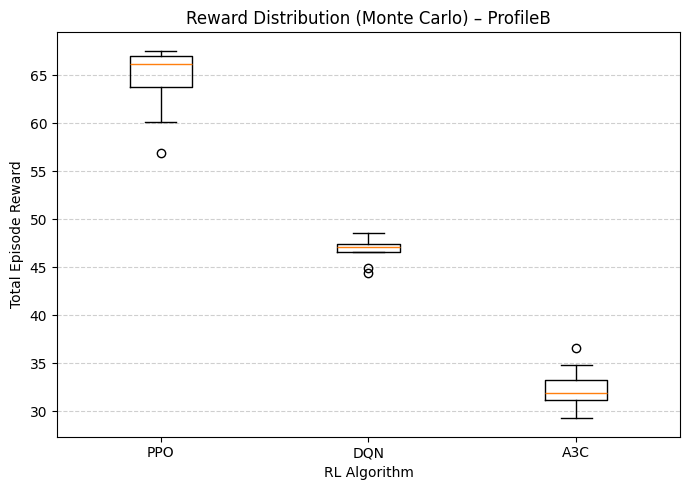

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# Load rollout-level reward data
# -------------------------------------------------
csv_path = "/content/reward_rollout_all_models_mc.csv"
df = pd.read_csv(csv_path)

# Basic sanity check
required_cols = {"Model", "Profile", "Reward"}
assert required_cols.issubset(df.columns), \
    f"CSV must contain columns: {required_cols}"

# -------------------------------------------------
# Helper function to plot boxplot for one profile
# -------------------------------------------------
def plot_profile_boxplot(df, profile_name):
    """
    Plot reward distribution boxplot for a single profile.
    Each box corresponds to one RL algorithm.
    """

    df_p = df[df["Profile"] == profile_name]

    models = ["PPO", "DQN", "A3C"]
    data = [
        df_p[df_p["Model"] == m]["Reward"].values
        for m in models
    ]

    plt.figure(figsize=(7, 5))
    plt.boxplot(
        data,
        labels=models,
        showfliers=True
    )

    plt.title(f"Reward Distribution (Monte Carlo) – {profile_name}")
    plt.xlabel("RL Algorithm")
    plt.ylabel("Total Episode Reward")

    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# -------------------------------------------------
# Plot Profile B
# -------------------------------------------------
plot_profile_boxplot(df, "ProfileB")


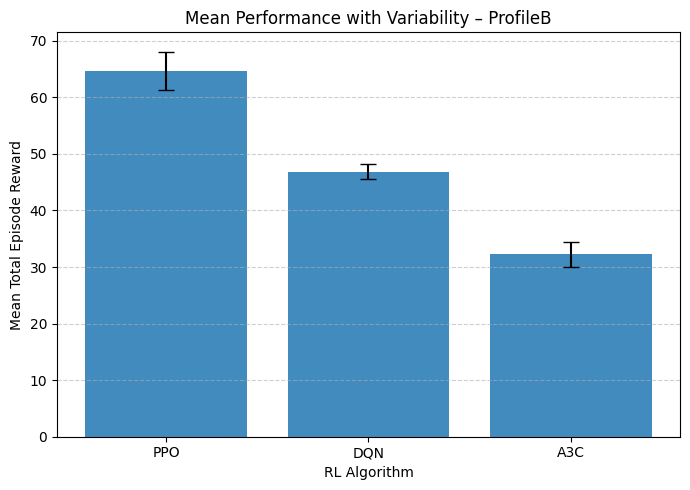

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Load Monte Carlo summary results
# -------------------------------------------------
csv_path = "/content/reward_comparison_all_models_mc.csv"
df = pd.read_csv(csv_path)

# -------------------------------------------------
# Helper: plot mean reward with std as error bar
# -------------------------------------------------
def plot_mean_reward(df, profile_name):
    """
    Plot mean total reward with standard deviation as error bars
    for a given profile.
    """

    df_p = df[df["Profile"] == profile_name]

    models = ["PPO", "DQN", "A3C"]
    means = []
    stds = []

    for m in models:
        row = df_p[df_p["Model"] == m].iloc[0]
        means.append(row["Reward_Mean"])
        stds.append(row["Reward_Std"])

    x = np.arange(len(models))

    plt.figure(figsize=(7, 5))
    plt.bar(
        x,
        means,
        yerr=stds,
        capsize=6,
        alpha=0.85
    )

    plt.xticks(x, models)
    plt.xlabel("RL Algorithm")
    plt.ylabel("Mean Total Episode Reward")
    plt.title(f"Mean Performance with Variability – {profile_name}")

    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# -------------------------------------------------
# Plot Profile B
# -------------------------------------------------
plot_mean_reward(df, "ProfileB")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# Load per-rollout assign_fail data
# -------------------------------------------------
df = pd.read_csv("/content/reassign_fail_rollout_all_models_mc.csv")

# -------------------------------------------------
# Create combined label: Algorithm + Profile
# -------------------------------------------------
df["Case"] = df["Model"] + "_" + df["Profile"]

# -------------------------------------------------
# Plot configuration
# -------------------------------------------------
plt.figure(figsize=(9, 6))

# Unique cases (6 lines)
cases = df["Case"].unique()

for case in cases:
    sub = df[df["Case"] == case].sort_values("Run_ID")
    plt.plot(
        sub["Run_ID"],
        sub["Assign_Fail"],
        marker="o",
        linewidth=2,
        label=case
    )

# -------------------------------------------------
# Axis & style
# -------------------------------------------------
plt.xlabel("Monte Carlo Run Index")
plt.ylabel("Number of Assign-Fail Decisions")
plt.title("Assign-Fail Trend Across Stochastic Rollouts")

plt.xticks(range(1, df["Run_ID"].max() + 1))
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Algorithm_Profile", ncol=2)

plt.tight_layout()
plt.show()


KeyError: 'Assign_Fail'

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<Figure size 900x600 with 0 Axes>